## Comprobar el entorno de  Qiskit <a id="install"></a>
En este Notebook se utilizar Qiskit para el diseño e implementación de circuitos cuánticos en simuladores y hardware real. Ya suponemos instalado Qiskit v2.0.
Lo primero, se comprueba la versión de Python del entorno y debe ser python>=3.10 para asegurar que sea compatible con la versión de Qiskit:

In [1]:
from platform import python_version

print(python_version())

3.11.0


In [2]:
import qiskit

print(f"Qiskit version: {qiskit.__version__}")


Qiskit version: 2.2.3


En este entorno la version de Qiskit `>=2.0.0`

## Imports <a id="imports"></a>


In [4]:
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

from qiskit_aer import AerSimulator


## Creación de un circuito con registros cuánticos explícitos

Se va a crear un circuito cuántico muy simple para comprobar que todo funciona como se espera.

In [5]:
from qiskit import QuantumRegister, QuantumCircuit
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_bloch_multivector
import numpy as np
# Importing standard Qiskit libraries
from qiskit.visualization import *

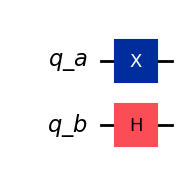

In [6]:

# Aquí creamos 2 registros cuánticos explícitamente antes de crear nuestro circuito
# Y obtenemos el vector de estado de la misma manera
# Luego representamos su multivector de Bloch

#from qiskit import QuantumRegister, QuantumCircuit, BasicAer, execute
#from qiskit.visualization import plot_bloch_multivector

# Creamos dos registros cuánticos de 1 qubit cada uno
q_a = QuantumRegister(1, 'q_a')  # Registro cuántico llamado 'q_a'
q_b = QuantumRegister(1, 'q_b')  # Registro cuántico llamado 'q_b'

# Creamos un circuito cuántico que usa ambos registros
qc = QuantumCircuit(q_a, q_b)

# Aplicamos una puerta Hadamard al primer qubit (índice 0)
qc.x(0)

# Aplicamos una puerta X al mismo qubit
qc.h(1)

qc.draw('mpl')

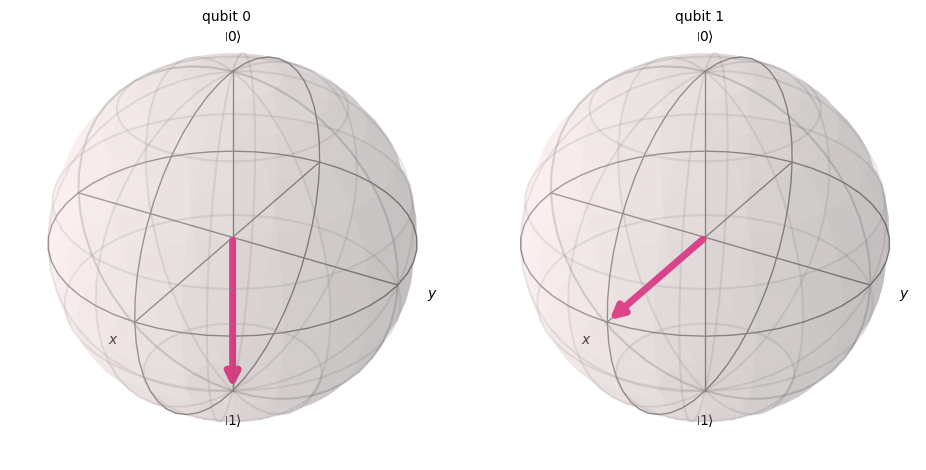

In [7]:

# Usar el simulador de vectores de estado
backend = Aer.get_backend('statevector_simulator')

# Ejecutamos el circuito en el simulador
compiled_circuit = transpile(qc, backend)
result = backend.run(compiled_circuit).result()

# Obtenemos el vector de estado resultante
sv = result.get_statevector()

# Representamos el multivector de Bloch del estado cuántico
plot_bloch_multivector(sv)  # ¡Voilà!

## Añadimos más puertas al circuito

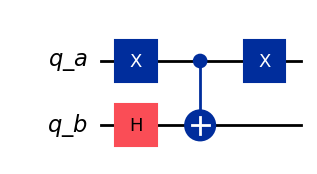

In [8]:
# Aplicamos una puerta CX 
qc.cx(q_a, q_b)
# Aplicamos una puerta CX 
qc.x(q_a)

qc.draw('mpl')

In [9]:
# Ejecutamos el circuito en el simulador
compiled_circuit = transpile(qc, backend)
result = backend.run(compiled_circuit).result()

# Obtenemos el vector de estado resultante
sv = result.get_statevector()
sv

Statevector([0.70710678+0.j, 0.        +0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))


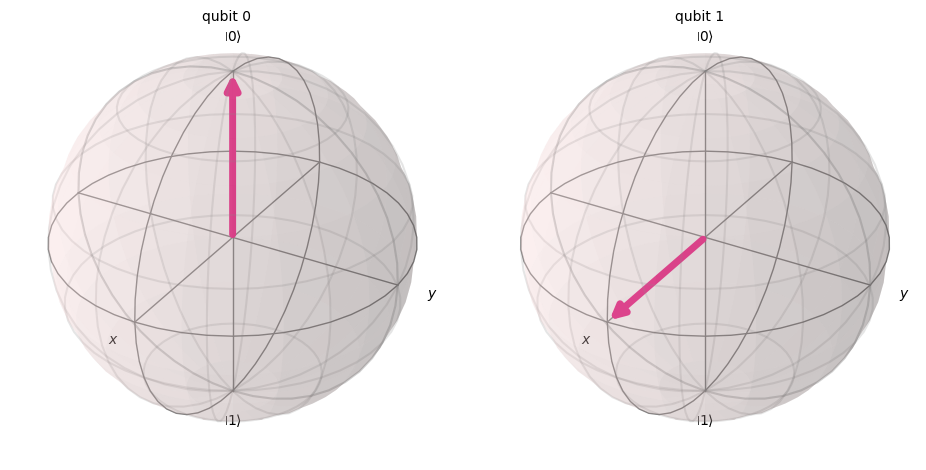

In [11]:
# Representamos el multivector de Bloch del estado cuántico
plot_bloch_multivector(sv)  # ¡Voilà!

In [12]:
from qiskit.quantum_info import Operator
U = Operator(qc) # ¡podemos convertir nuestro circuito qc anterior en un operador!
U.data

# NOTA: esto es muy similar a obtener directamente el objeto Statevector,
# solo que esta vez, para obtener el operador,
# veremos que también se puede hacer mediante simulación,
# al igual que hicimos con el estado

array([[ 0.70710678+0.j,  0.        +0.j, -0.70710678+0.j,
         0.        +0.j],
       [ 0.        +0.j,  0.70710678+0.j,  0.        +0.j,
         0.70710678+0.j],
       [ 0.70710678+0.j,  0.        +0.j,  0.70710678+0.j,
         0.        +0.j],
       [ 0.        +0.j,  0.70710678+0.j,  0.        +0.j,
        -0.70710678+0.j]])

In [13]:
# si así lo deseamos, podemos redondear todos estos números usando np.around
# y especificar cuántos decimales queremos
np.around(U.data, 3)

array([[ 0.707+0.j,  0.   +0.j, -0.707+0.j,  0.   +0.j],
       [ 0.   +0.j,  0.707+0.j,  0.   +0.j,  0.707+0.j],
       [ 0.707+0.j,  0.   +0.j,  0.707+0.j,  0.   +0.j],
       [ 0.   +0.j,  0.707+0.j,  0.   +0.j, -0.707+0.j]])

## También podríamos hacerlo con unitary_sim, al igual que hicimos con statevector_sim

In [14]:
backend_uni = Aer.get_backend('unitary_simulator') # obtenemos el simulador unitario

# Compilar el circuito
compiled_circuit = transpile(qc, backend_uni)

# Ejecutar directamente con backend.run()
result = backend_uni.run(compiled_circuit).result()
U1 = result.get_unitary(decimals=3)

# en lugar de redondear con np.around(), también puedes usar 'decimals' en get_unitary como se muestra arriba
#ver le operador U
U1


Operator([[ 0.707+0.j,  0.   +0.j, -0.707+0.j,  0.   +0.j],
          [ 0.   +0.j,  0.707+0.j,  0.   +0.j,  0.707-0.j],
          [ 0.707+0.j,  0.   +0.j,  0.707-0.j,  0.   +0.j],
          [ 0.   +0.j,  0.707+0.j,  0.   +0.j, -0.707+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


## Se puede extender un circuito ya definido con "Compose"

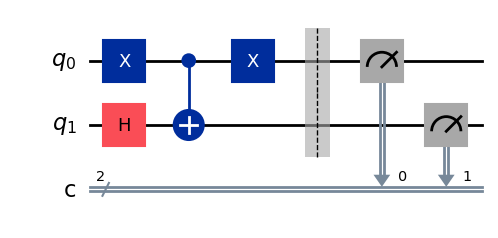

In [15]:

# Aquí creamos un nuevo circuito cuántico solo con una barrera y mediciones
measqc = QuantumCircuit(2, 2)

# Insertamos una barrera para separar visualmente las operaciones
measqc.barrier()

# Medimos los qubits 0, 1  en los bits clásicos 0, 1 2 respectivamente
# Nota: no necesitamos escribir tres líneas de medición gracias al uso de listas []
# Además, cada qubit se mide en su correspondiente bit clásico — ¡el orden importa!
measqc.measure([0, 1], [0, 1])

# Componemos el circuito GHZ con el circuito de medición
# El método compose requiere el circuito que queremos combinar
# El parámetro front=True asegura que el circuito GHZ se ejecute antes de las mediciones
circq = measqc.compose(qc, range(2), front=True)

# Dibujamos el circuito completo usando estilo matplotlib
circq.draw('mpl')


In [16]:
## Simulación con Shots ( QASM) mas cercana al QC físico

In [17]:
backend = Aer.get_backend('qasm_simulator')
circq = transpile(circq, backend)
job = backend.run(circq, shots=1024) # nota: aquí usamos .run en lugar de execute, esto muestra que también se puede hacer
#  'execute' se usabe en versiones previas de qiskit pero se ha deprecado
result = job.result()
counts = result.get_counts()
print(counts) # ahora, también podríamos simplemente imprimir los resultados de forma poco espectacular en comparación con graficar los histogramas


{'00': 504, '10': 520}


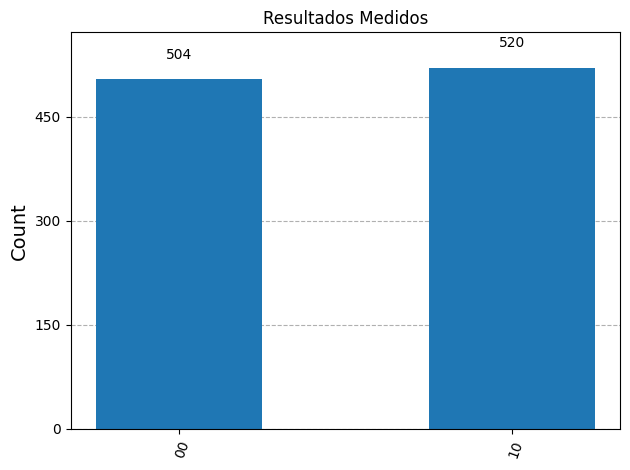

In [18]:
display(plot_histogram(counts, title="Resultados Medidos"))

## Otra ejecución del mismo circuito

In [19]:
job2 = backend.run(circq, shots=1024) 
#  'execute' se usabe en versiones previas de qiskit pero se ha deprecado
result2 = job2.result()
counts2 = result2.get_counts()
print(counts2) 
# aquí también demostramos la naturaleza probabilística de la medición cuántica,
# como puedes ver, los resultados son diferentes en dos experimentos distintos sobre el mismo circuito


{'10': 514, '00': 510}


## Representar los dos resultados

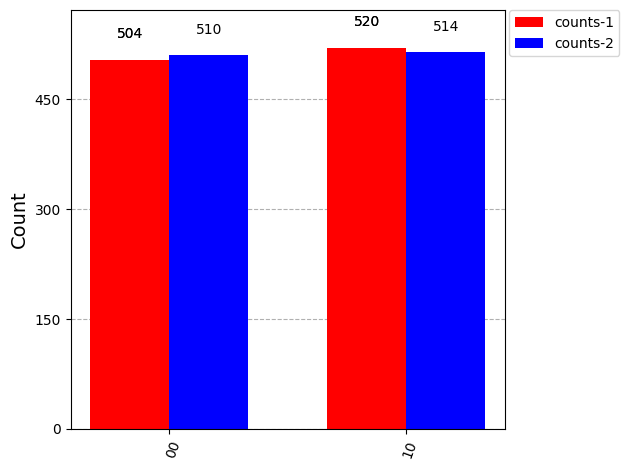

In [20]:

leg = ['counts-1','counts-2']
plot_histogram([counts,counts2], legend=leg, sort='asc', color=['red','blue']) 
# también hay una forma de no mostrar las probabilidades ENCIMA de las barras usando el parámetro bar_labels=False
# para el resto de los métodos, ¡consulta la documentación!


## Ejemplo de creación de un circuito directamente <a id="sanity-check"></a>

Se va a crear un circuito cuántico sin indicar explicitamente los registros cuánticos.

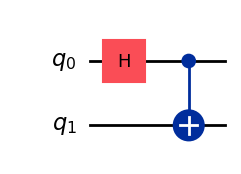

In [21]:
# Create a new circuit with a single qubit
qc = QuantumCircuit(2)
# Add a H gate to qubit 0
qc.h(0)
# Add a CNOT gate to qubit 1
qc.cx(0, 1)
# Return a drawing of the circuit using MatPlotLib ("mpl").
qc.draw("mpl")

La salida  de este circuito cuántico produce un estado de Bell:

$$|Bell\rangle=\frac{|00\rangle+|11\rangle}{\sqrt{2}}$$

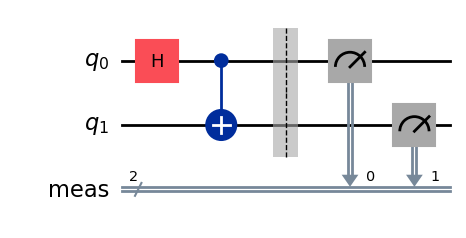

In [22]:
# Add measurement operations
qc.measure_all()
#
qc.draw("mpl")

## Simulación del  circuito sin transpilar

Simulación con shots (QASM) en Aer Simulator 

In [23]:
# Set up the backend
backend = AerSimulator()

# Set up the sampler
sampler = Sampler(mode=backend)

# Submit the circuit to Sampler
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
job = sampler.run(pm.run([qc]))

# Get the results
results_sampler = job.result()

In [24]:
results_sampler

PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024, 'circuit_metadata': {}})], metadata={'version': 2})

In [25]:
counts = results_sampler[0].data.meas.get_counts()
print(counts) #now, we could also just print our counts in an un-spectacular way compared to plotting the histograms!

{'00': 519, '11': 505}


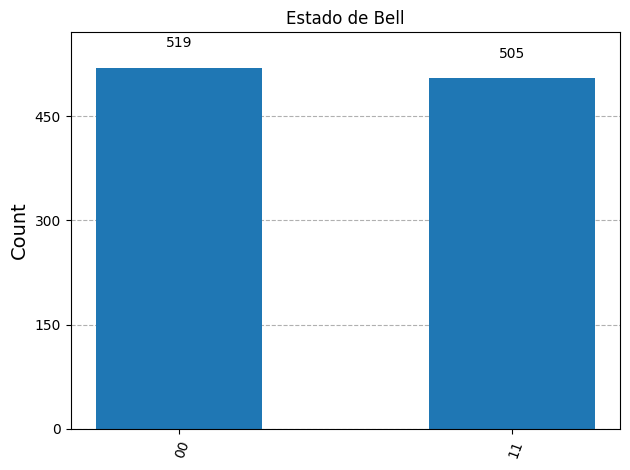

In [26]:
display(plot_histogram(counts, title="Estado de Bell"))

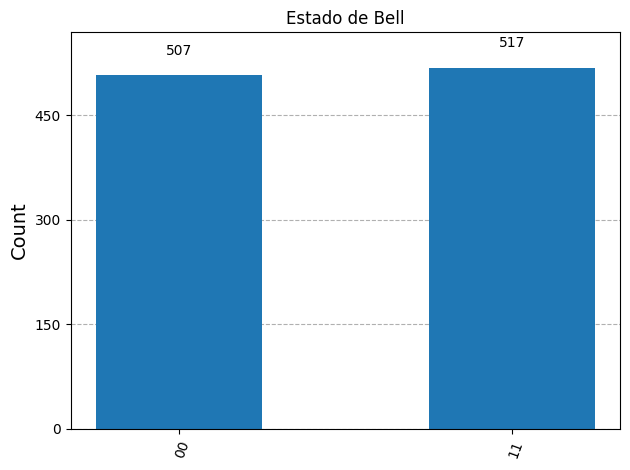

In [27]:
job1 = sampler.run(pm.run([qc]))
results1 = job1.result()
counts1 = results1[0].data.meas.get_counts()
display(plot_histogram(counts1, title="Estado de Bell"))